#### Problem Statement:
A mall wants to understand its customer base better in order to improve its marketing strategy. The goal is to segment customers into different groups based on their Annual Income and Spending Score, so that the marketing team can design targeted campaigns according to each group’s preferences and behavior.

In [1]:
import numpy as np                  # Numerical Operations 
import pandas as pd                 # Data Handling 
import matplotlib.pyplot as plt     # Visualization 

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score , davies_bouldin_score

In [2]:
# Step 2 : Load Dataset 
df = pd.read_csv("mall_customers_kmeans_dataset.csv")   # Load dataset

print(df.head())    # Sample Data
print(df.shape)   # dataset size 
print(df.info())    # Structure
print(df.describe())# Statistics 

   CustomerID  AnnualIncome  SpendingScore  Cluster CustomerSegment
0           1         37483             27        2             NaN
1           2         34308             21        2             NaN
2           3         38238             19        2             NaN
3           4         42615             29        2             NaN
4           5         33829             33        2             NaN
(200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   CustomerID       200 non-null    int64 
 1   AnnualIncome     200 non-null    int64 
 2   SpendingScore    200 non-null    int64 
 3   Cluster          200 non-null    int64 
 4   CustomerSegment  93 non-null     object
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
       CustomerID  AnnualIncome  SpendingScore     Cluster
count  200.000000     200.00000     200.000000  20

In [3]:
# Step 3 : Select Features 
X = df[["AnnualIncome" , "SpendingScore"]]   # Select features 


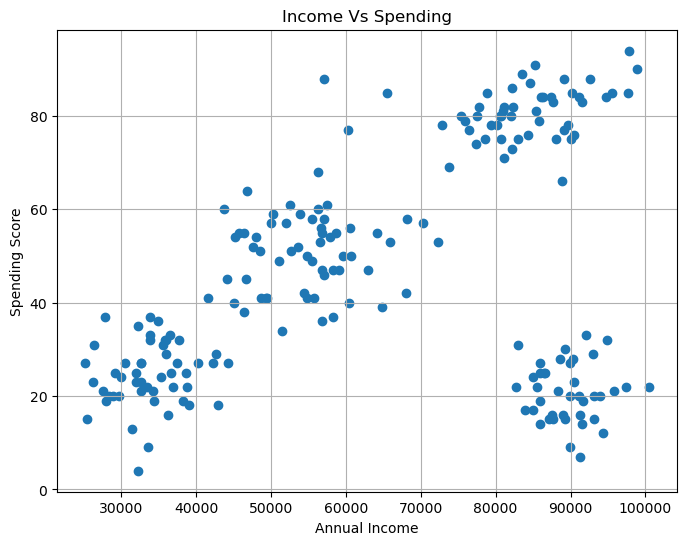

In [4]:
# Step 4 : Scatter Plot 
plt.figure(figsize=(8,6))
plt.scatter(df["AnnualIncome"] , df["SpendingScore"])  # Basic Visualization
plt.title("Income Vs Spending")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.grid(True)
plt.savefig("images/Income Vs Spending.png")
plt.show()

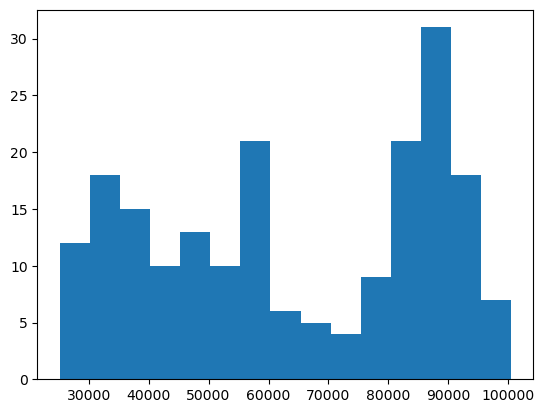

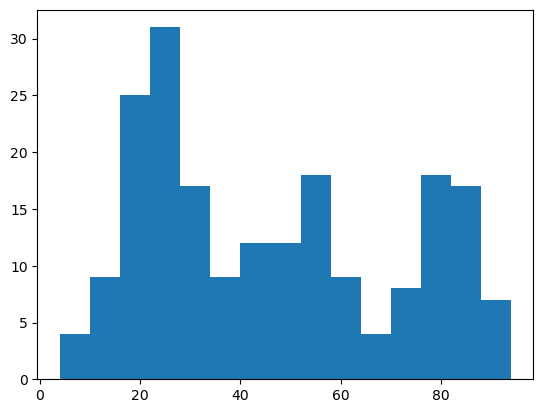

In [5]:
# Step 5 : Histograms
plt.hist(df["AnnualIncome"] , bins=15)   # Income distribution
plt.savefig("images/AnnualIncome.png")
plt.show()
plt.hist(df["SpendingScore"] , bins=15)  # Spending  Distribution
plt.savefig("images/SpendingScore.png")
plt.show()

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Window

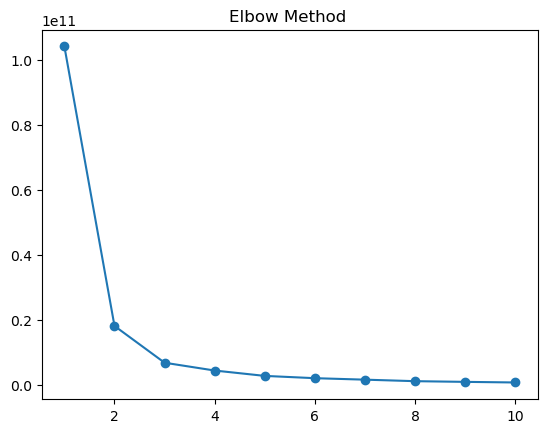

In [6]:
# Step 6 : Elbow Method 
wcss = [] # Store WCSS

for i in range(1 , 11):
    km = KMeans(n_clusters=i , random_state= 42 , n_init= 10)
    km.fit(X)
    wcss.append(km.inertia_)  # save inertia
    
plt.plot(range(1,11) , wcss , marker = 'o')
plt.title("Elbow Method ")
plt.savefig("images/Elbow Method.png")
plt.show()

In [7]:
# Step 7 : Apply KMeans
kmeans = KMeans(n_clusters=4 , random_state=42 , n_init=10)
df["Cluster"] = kmeans.fit_predict(X)   # Assign Clusters
print(df.head())

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


   CustomerID  AnnualIncome  SpendingScore  Cluster CustomerSegment
0           1         37483             27        2             NaN
1           2         34308             21        2             NaN
2           3         38238             19        2             NaN
3           4         42615             29        2             NaN
4           5         33829             33        2             NaN


In [8]:
# Step 8 : Cluster centers
centroids = kmeans.cluster_centers_  # Get centroids
print(centroids)

[[5.47074259e+04 5.20555556e+01]
 [9.01370492e+04 4.50655738e+01]
 [3.43974906e+04 2.59811321e+01]
 [7.86689375e+04 7.01562500e+01]]


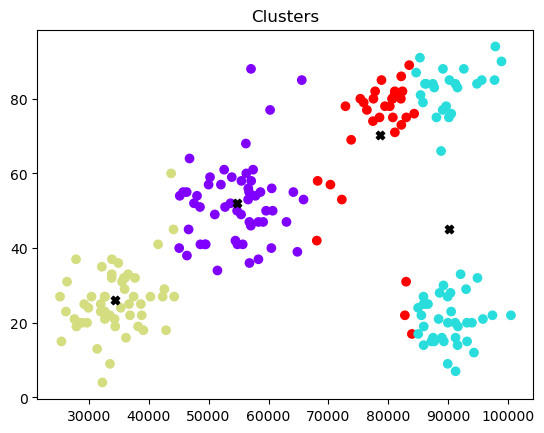

In [9]:
# Step 9 : Cluster Visualization
plt.scatter(df["AnnualIncome"] , df["SpendingScore"] , c=df["Cluster"] , cmap="rainbow")
plt.scatter(centroids[:,0] , centroids[:,1] , c="black" , marker="X")
plt.title("Clusters")
plt.savefig("images/Clusters.png")
plt.show()

Cluster
1    61
0    54
2    53
3    32
Name: count, dtype: int64


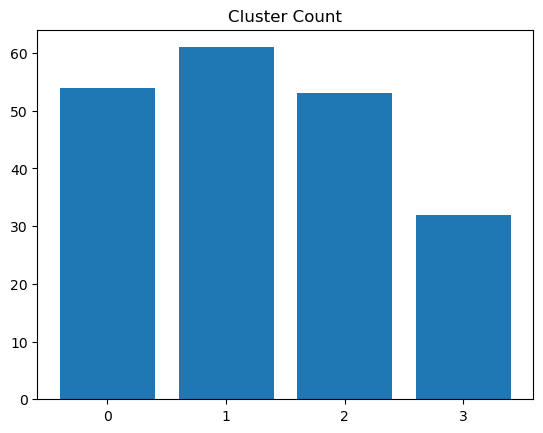

In [10]:
# Step 10 : Cluster Count 
print(df["Cluster"].value_counts())   # Cluster distribution
cluster_counts = df["Cluster"].value_counts().sort_index()
plt.bar(cluster_counts.index.astype(str) , cluster_counts.values)
plt.title("Cluster Count")
plt.savefig("images/Cluster Count.png")
plt.show()

In [11]:
# Step 11 : Evalution Metrics 
print("Silhouette:", silhouette_score(X,df["Cluster"]))  # Separation
print("DB Score:", davies_bouldin_score(X , df["Cluster"]))  # Overlap
print("Inertia : " , kmeans.inertia_)  # Compactness


Silhouette: 0.6042891716799604
DB Score: 0.5019999596966818
Inertia :  4462208746.947366


In [12]:
# Step 12 : Cluster Analysis 
cluster_summary = df.groupby("Cluster")[["AnnualIncome" , "SpendingScore"]].mean()
print(cluster_summary)  # cluster Average


         AnnualIncome  SpendingScore
Cluster                             
0        54707.425926      52.055556
1        90137.049180      45.065574
2        34397.490566      25.981132
3        78668.937500      70.156250


In [13]:
# Step 13 : Business Lables 
cluster_labels = {}

for i in cluster_summary.index:
    inc = cluster_summary.loc[i , "AnnualIncome"]
    scr = cluster_summary.loc[i , "SpendingScore"]
    
    if inc > 70000 and scr >=60 : 
        cluster_labels[i] = "Premium Customers"
    elif inc >= 70000 :
        cluster_labels[i] = "Careful Rich Customers"
    elif scr >= 60:
        cluster_labels[i] = "Impulsive Buyers"
    elif scr >= 60 :
        cluster_labels[i] = "Budget Customers"
df["CustomerSegment"] = df["Cluster"].map(cluster_labels)
print(df.head())

   CustomerID  AnnualIncome  SpendingScore  Cluster CustomerSegment
0           1         37483             27        2             NaN
1           2         34308             21        2             NaN
2           3         38238             19        2             NaN
3           4         42615             29        2             NaN
4           5         33829             33        2             NaN


CustomerSegment
Careful Rich Customers    61
Premium Customers         32
Name: count, dtype: int64


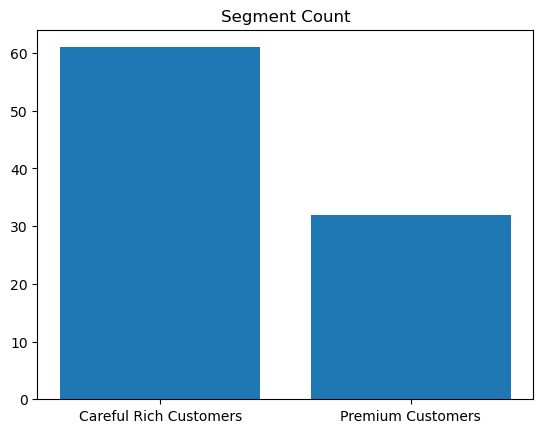

In [14]:
# Step 14 : Segment Count
print(df["CustomerSegment"].value_counts())  # Segment distribution 

segment_counts = df["CustomerSegment"].value_counts()

plt.bar(segment_counts.index , segment_counts.values)
plt.title("Segment Count")
plt.savefig("images/Segment Count")
plt.show()

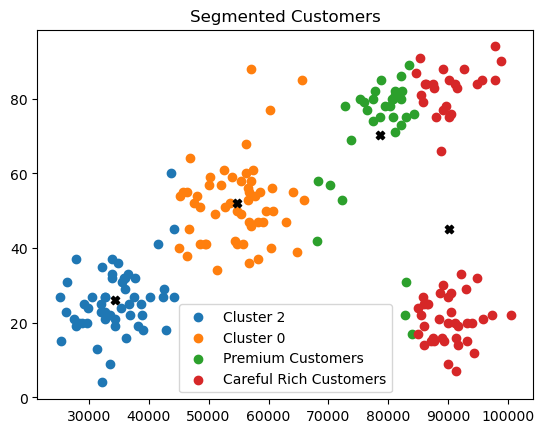

In [15]:
# Step 15 : Business Visualization
for i in df["Cluster"].unique():
    data = df[df["Cluster"] == i]

    plt.scatter(
        data["AnnualIncome"],
        data["SpendingScore"],
        label=cluster_labels.get(i, f"Cluster {i}")  # safe fix
    )

plt.scatter(centroids[:,0], centroids[:,1], c="black", marker="X")
plt.legend()
plt.title("Segmented Customers")

plt.savefig("images/Segmented Customers.png")
plt.show()

In [16]:
# Step 16 : Marketing Strategy
for label in set(cluster_labels.values()):
    if label == "Premium Customer":
        print("Premium - Luxury offers")
    elif label == "Careful Rich Customers":
        print("Careful - Value offers")
    elif label == "Impulsive Buyers":
        print("Impulsive - Flash sales")
    else:
        print("Budget - Discounts")
        

Budget - Discounts
Careful - Value offers


In [17]:
# Step 17  : New Customer Prediction 
new = pd.DataFrame({"AnnualIncome":[75000] , "SpendingScore":[70]})

cluster = kmeans.predict(new)[0]
segment = cluster_labels[cluster]

print(cluster , segment)

3 Premium Customers


In [18]:
# Step 18 : Save Output 
df.to_csv("mall_customers_kmeans_dataset.csv" , index=False)
print("File Saved")

File Saved
